In [1]:
# 라이브러리 임포트
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8')
%matplotlib inline

# 포트폴리오 데이터 다시 로드
portfolio_full = {
    'JEPI':  120.25,
    'SCHD':  233.46,
    'PDBC':  391.58,
    'TSLA':  18.22,
    'CRCL':  55.25,
    'KODEX': 1600,
}

tickers_us = ['JEPI', 'SCHD', 'PDBC', 'TSLA', 'CRCL']
prices_us = yf.download(tickers_us, start='2025-06-05', end='2026-04-12')['Close']

# 환율 및 KODEX
usdkrw = yf.download('KRW=X', start='2025-06-05', end='2026-04-12')['Close'].squeeze()
kodex_prices = yf.download('476800.KS', start='2025-06-05', end='2026-04-12')['Close'].squeeze()
kodex_prices.index = kodex_prices.index.tz_localize(None)
kodex_usd = kodex_prices / usdkrw

prices_full = prices_us.copy()
prices_full['KODEX'] = kodex_usd
prices_full = prices_full.dropna()

tickers_full = list(portfolio_full.keys())
shares_full = pd.Series(portfolio_full)
latest_prices = prices_full.iloc[-1]
market_value = shares_full * latest_prices
total_value = float(market_value.sum())
weights_full = market_value / total_value

returns_full = prices_full.pct_change().dropna()

print("데이터 로드 완료!")
print(f"총 평가금액: ${total_value:,.2f}")

[*********************100%***********************]  5 of 5 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

데이터 로드 완료!
총 평가금액: $37,329.25


In [2]:
# 몬테카를로 시뮬레이션
np.random.seed(42)

n_simulations = 1000  # 시뮬레이션 횟수
n_days = 252          # 1년 (거래일 기준)

# 수익률 통계
mean_returns = returns_full.mean()
cov_matrix = returns_full.cov()

# 시뮬레이션 실행
simulation_results = np.zeros((n_days, n_simulations))
simulation_results[0] = total_value

for sim in range(n_simulations):
    daily_returns = np.random.multivariate_normal(
        mean_returns, cov_matrix, n_days
    )
    portfolio_daily = (daily_returns * weights_full.values).sum(axis=1)
    
    cumulative = total_value
    for day in range(n_days):
        cumulative = cumulative * (1 + portfolio_daily[day])
        simulation_results[day, sim] = cumulative

print(f"시뮬레이션 완료! ({n_simulations}개 시나리오 x {n_days}일)")
print(f"\n=== 1년 후 포트폴리오 가치 예측 ===")
final_values = simulation_results[-1]
print(f"평균: ${np.mean(final_values):,.2f}")
print(f"중앙값: ${np.median(final_values):,.2f}")
print(f"최대: ${np.max(final_values):,.2f}")
print(f"최소: ${np.min(final_values):,.2f}")

시뮬레이션 완료! (1000개 시나리오 x 252일)

=== 1년 후 포트폴리오 가치 예측 ===
평균: $51,031.61
중앙값: $49,833.02
최대: $97,515.67
최소: $23,659.43


=== VaR (Value at Risk) 분석 ===
현재 포트폴리오 가치: $37,329.25
95% VaR: $35,115.21 (손실 하한: $2,214.04)
99% VaR: $30,462.01 (손실 하한: $6,867.25)
수익 확률: 90.4%


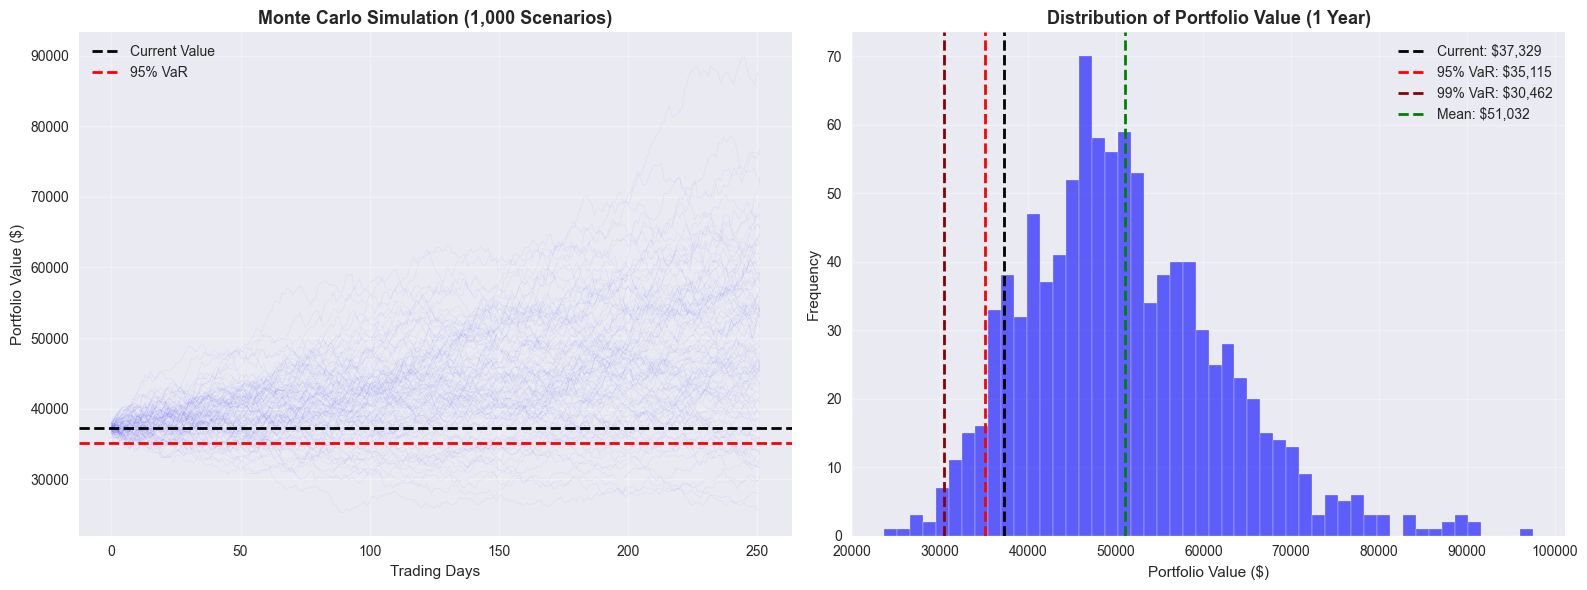

In [3]:
# VaR 계산 및 시각화
var_95 = np.percentile(final_values, 5)
var_99 = np.percentile(final_values, 1)
prob_profit = (final_values > total_value).sum() / n_simulations * 100

print("=== VaR (Value at Risk) 분석 ===")
print(f"현재 포트폴리오 가치: ${total_value:,.2f}")
print(f"95% VaR: ${var_95:,.2f} (손실 하한: ${total_value - var_95:,.2f})")
print(f"99% VaR: ${var_99:,.2f} (손실 하한: ${total_value - var_99:,.2f})")
print(f"수익 확률: {prob_profit:.1f}%")

# 시뮬레이션 경로 차트
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 왼쪽: 시뮬레이션 경로
for sim in range(0, n_simulations, 10):
    axes[0].plot(simulation_results[:, sim], 
                 alpha=0.05, color='blue', linewidth=0.5)

axes[0].axhline(y=total_value, color='black', 
                linestyle='--', linewidth=2, label='Current Value')
axes[0].axhline(y=var_95, color='red', 
                linestyle='--', linewidth=2, label='95% VaR')
axes[0].set_title('Monte Carlo Simulation (1,000 Scenarios)', 
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel('Trading Days')
axes[0].set_ylabel('Portfolio Value ($)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 오른쪽: 최종 가치 분포
axes[1].hist(final_values, bins=50, color='blue', alpha=0.6, edgecolor='white')
axes[1].axvline(x=total_value, color='black', 
                linestyle='--', linewidth=2, label=f'Current: ${total_value:,.0f}')
axes[1].axvline(x=var_95, color='red', 
                linestyle='--', linewidth=2, label=f'95% VaR: ${var_95:,.0f}')
axes[1].axvline(x=var_99, color='darkred', 
                linestyle='--', linewidth=2, label=f'99% VaR: ${var_99:,.0f}')
axes[1].axvline(x=np.mean(final_values), color='green', 
                linestyle='--', linewidth=2, label=f'Mean: ${np.mean(final_values):,.0f}')
axes[1].set_title('Distribution of Portfolio Value (1 Year)', 
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('Portfolio Value ($)')
axes[1].set_ylabel('Frequency')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [4]:
# 최적 비중으로 몬테카를로 재실행
from scipy.optimize import minimize

def neg_sharpe(w, returns):
    port_return = np.sum(returns.mean() * w) * 252
    port_vol = np.sqrt(np.dot(w.T, np.dot(returns.cov() * 252, w)))
    return -port_return / port_vol

constraints = {'type': 'eq', 'fun': lambda x: np.sum(x) - 1}
bounds = tuple((0, 1) for _ in range(len(tickers_full)))
init_weights = np.array([1/len(tickers_full)] * len(tickers_full))

result = minimize(neg_sharpe, init_weights,
                  args=(returns_full,),
                  method='SLSQP',
                  bounds=bounds,
                  constraints=constraints)
optimal_weights = result.x

# 최적 비중으로 시뮬레이션
simulation_optimal = np.zeros((n_days, n_simulations))
simulation_optimal[0] = total_value

for sim in range(n_simulations):
    daily_returns = np.random.multivariate_normal(
        mean_returns, cov_matrix, n_days
    )
    portfolio_daily = (daily_returns * optimal_weights).sum(axis=1)
    
    cumulative = total_value
    for day in range(n_days):
        cumulative = cumulative * (1 + portfolio_daily[day])
        simulation_optimal[day, sim] = cumulative

final_optimal = simulation_optimal[-1]
var_95_opt = np.percentile(final_optimal, 5)
prob_profit_opt = (final_optimal > total_value).sum() / n_simulations * 100

print("=== 현재 vs 최적 포트폴리오 비교 ===")
print(f"{'':20} {'현재':>12} {'최적':>12}")
print("-" * 45)
print(f"{'평균 예상가치':<20} ${np.mean(final_values):>10,.0f} ${np.mean(final_optimal):>10,.0f}")
print(f"{'95% VaR':<20} ${var_95:>10,.0f} ${var_95_opt:>10,.0f}")
print(f"{'수익 확률':<20} {prob_profit:>10.1f}% {prob_profit_opt:>10.1f}%")

=== 현재 vs 최적 포트폴리오 비교 ===
                               현재           최적
---------------------------------------------
평균 예상가치              $    51,032 $    47,756
95% VaR              $    35,115 $    41,723
수익 확률                      90.4%       99.8%


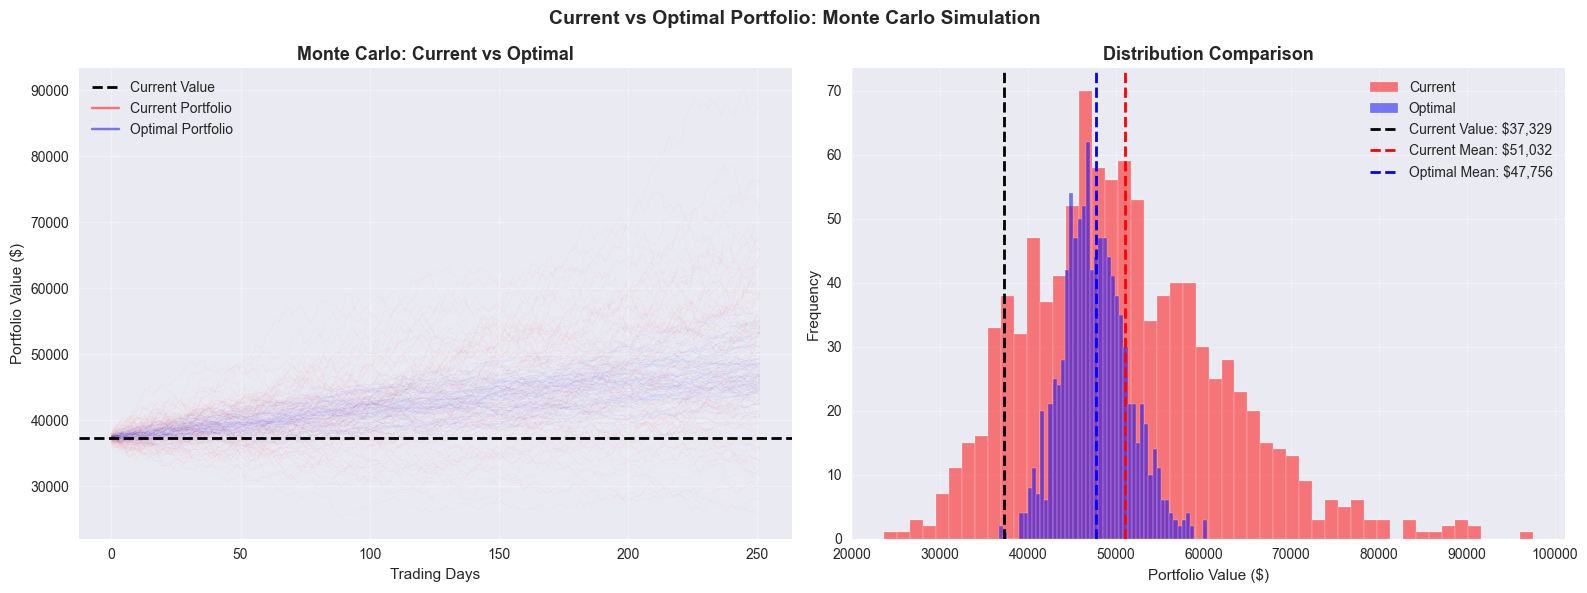


✅ 몬테카를로 시뮬레이션 완료!


In [5]:
# 현재 vs 최적 포트폴리오 비교 차트
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 왼쪽: 시뮬레이션 경로 비교
for sim in range(0, n_simulations, 10):
    axes[0].plot(simulation_results[:, sim],
                 alpha=0.03, color='red', linewidth=0.5)
    axes[0].plot(simulation_optimal[:, sim],
                 alpha=0.03, color='blue', linewidth=0.5)

axes[0].axhline(y=total_value, color='black',
                linestyle='--', linewidth=2, label='Current Value')
axes[0].plot([], [], color='red', alpha=0.5, label='Current Portfolio')
axes[0].plot([], [], color='blue', alpha=0.5, label='Optimal Portfolio')
axes[0].set_title('Monte Carlo: Current vs Optimal', 
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel('Trading Days')
axes[0].set_ylabel('Portfolio Value ($)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 오른쪽: 최종 가치 분포 비교
axes[1].hist(final_values, bins=50, alpha=0.5, 
             color='red', label='Current', edgecolor='white')
axes[1].hist(final_optimal, bins=50, alpha=0.5,
             color='blue', label='Optimal', edgecolor='white')
axes[1].axvline(x=total_value, color='black',
                linestyle='--', linewidth=2, label=f'Current Value: ${total_value:,.0f}')
axes[1].axvline(x=np.mean(final_values), color='red',
                linestyle='--', linewidth=2, label=f'Current Mean: ${np.mean(final_values):,.0f}')
axes[1].axvline(x=np.mean(final_optimal), color='blue',
                linestyle='--', linewidth=2, label=f'Optimal Mean: ${np.mean(final_optimal):,.0f}')
axes[1].set_title('Distribution Comparison', 
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('Portfolio Value ($)')
axes[1].set_ylabel('Frequency')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Current vs Optimal Portfolio: Monte Carlo Simulation',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n✅ 몬테카를로 시뮬레이션 완료!")